## Core Marketing Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_customer = pd.read_csv('customer_list.csv',sep='|')
df_categories = pd.read_csv('ProductCategories.csv')
df_product = pd.read_csv('Products.csv')
df_store = pd.read_csv('StoreDetail.csv')
df_sales = pd.read_csv('StoreSales.csv')
df_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [5]:
print(df_store.columns)

Index(['Store Location', 'State', 'Store ID', 'Territory Manager', 'Region',
       'Region Director'],
      dtype='str')


### Territory Manager, Store IDs, and Cities

In [6]:
# Filter territories managed by Lana Ilana 
target_manager = 'Lana Ilana'
lana_stores = df_store[df_store['Territory Manager'] == target_manager]

In [7]:
# Display Store IDs, Locations, and States for the assigned territories
assigned_stores_info = lana_stores[['Store ID', 'Store Location', 'State']]
print(f"Territory Manager: {target_manager}\n")
print(assigned_stores_info)

Territory Manager: Lana Ilana

    Store ID   Store Location    State
26       719   Cape Canaveral  Florida
27       720  Fort Lauderdale  Florida
28       721     Jacksonville  Florida
29       722         Key West  Florida
30       723         Lakeland  Florida
31       724            Miami  Florida
32       725           Naples  Florida
33       726          Orlando  Florida
34       727          Sebring  Florida
35       728      Tallahassee  Florida
36       729            Tampa  Florida


### Monthly Total Revenue for Assigned Territories

In [8]:
print(df_sales.columns)

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='str')


In [9]:
# Extract the Store IDs for Lana Ilana's territories
lana_store_ids = lana_stores['Store ID'].tolist()

In [10]:
# Filter the sales data to only include Lana's stores
lana_sales = df_sales[df_sales['Store ID'].isin(lana_store_ids)].copy()

In [11]:
# Formatting
lana_sales['Transaction Date'] = pd.to_datetime(lana_sales['Transaction Date'])
lana_sales['Month'] = lana_sales['Transaction Date'].dt.to_period('M')

In [12]:
# Group by Month and calculate total revenue
monthly_revenue = lana_sales.groupby('Month')['Sale Amount'].sum().reset_index()

In [13]:
# Rename columns
monthly_revenue.rename(columns={'Sale Amount': 'Revenue'}, inplace=True)
print(monthly_revenue)

      Month    Revenue
0   2022-01   48143.95
1   2022-02   46257.35
2   2022-03   53541.25
3   2022-04   49505.25
4   2022-05   58326.64
5   2022-06   48683.24
6   2022-07   57545.77
7   2022-08   48656.98
8   2022-09   42839.10
9   2022-10   49508.42
10  2022-11   44519.86
11  2022-12   50885.58
12  2023-01   70589.71
13  2023-02   74547.62
14  2023-03   71490.80
15  2023-04   71671.43
16  2023-05   76942.62
17  2023-06   75958.75
18  2023-07   74438.54
19  2023-08   71626.47
20  2023-09   86388.39
21  2023-10   76570.52
22  2023-11   81150.82
23  2023-12   85799.00
24  2024-01   83362.33
25  2024-02   65035.27
26  2024-03   73851.01
27  2024-04   74763.04
28  2024-05   78325.77
29  2024-06   72071.52
30  2024-07   71626.47
31  2024-08   90013.08
32  2024-09   72945.83
33  2024-10   83388.68
34  2024-11   83561.14
35  2024-12   70589.71
36  2025-01  118654.88
37  2025-02  105056.57
38  2025-03  108664.43
39  2025-04  117732.51
40  2025-05  125169.68
41  2025-06  101328.59
42  2025-07

In [14]:
# Group the filtered sales data by Store ID 
store_performance = lana_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()

In [15]:
# Sort the stores by total sales in descending order to see top performers
top_stores = store_performance.sort_values(by='Sale Amount', ascending=False)

In [16]:
# Rename the column to 'Revenue' to match the charts
top_stores.rename(columns={'Sale Amount': 'Revenue'}, inplace=True)
print(top_stores)

    Store ID    Revenue
5        724  618846.25
9        728  541670.66
3        722  332620.43
0        719  331956.13
2        721  331667.08
8        727  330848.14
10       729  308979.01
1        720  302270.07
7        726  297891.71
4        723  273835.24
6        725  259602.83


In [17]:
# Filter for transactions that have a Rewards ID 
rewards_sales = lana_sales[lana_sales['RewardsID'].notna()]

In [18]:
# Group by Rewards ID and sum the sale amount to find top spenders
top_spenders = rewards_sales.groupby('RewardsID')['Sale Amount'].sum().reset_index()

In [19]:
# Sort to get the top 5 customers
top_spenders = top_spenders.sort_values(by='Sale Amount', ascending=False).head(5)

In [20]:
# Cleaning
df_customer.columns = df_customer.columns.str.strip()
print(df_customer.columns)

Index(['cust_id', 'date', 'time', 'name', 'email', 'phone', 'sms-opt-out'], dtype='str')


In [21]:
# Merge with the correctly loaded customer list to get customer details
top_customers = pd.merge(top_spenders, df_customer, left_on='RewardsID', right_on='cust_id', how='left')
print(top_customers[['name', 'email', 'Sale Amount']])

               name                             email  Sale Amount
0        Stanley H.         stanley@dundermifflin.com      4954.99
1       Todd Chavez                 todd@hollywoo.net      4549.16
2              Huck  huck@oliviapopeandassociates.com      4415.78
3        John Locke           locke@dharma.initiative      3631.94
4  Dr. Ray Flemming                 flemming@lapd.gov      3535.88


In [22]:
print("Product columns:", df_product.columns)
print("Category columns:", df_categories.columns)

Product columns: Index(['Prod Num', 'Product', 'CategoryID', 'SubcategoryID'], dtype='str')
Category columns: Index(['CategoryID', 'Category', 'SubcategoryID', 'Subcategory'], dtype='str')


In [23]:
# Cleaning
sales_with_products = pd.merge(lana_sales, df_product, on='Prod Num', how='left')
sales_full = pd.merge(sales_with_products, df_categories, on='CategoryID', how='left')

In [24]:
# Grouping
category_monthly_stats = sales_full.groupby(['Month', 'Category']).agg(
    Transaction_Count=('Prod Num', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index()

category_monthly_stats = category_monthly_stats.sort_values(by=['Month', 'Total_Revenue'], ascending=[True, False])
print(category_monthly_stats.head(15))

      Month                  Category  Transaction_Count  Total_Revenue
4   2022-01  Technology & Accessories                525      228610.83
5   2022-01                 Textbooks                671      113160.41
1   2022-01              Art Supplies                693       21940.38
0   2022-01   Apparel and Merchandise                528       15845.52
3   2022-01   Stationery and Supplies                759        7365.38
2   2022-01           Books (General)                 80        2212.40
10  2022-02  Technology & Accessories                546      229376.70
11  2022-02                 Textbooks                506       85592.10
7   2022-02              Art Supplies                671       20523.47
6   2022-02   Apparel and Merchandise                488       16164.64
9   2022-02   Stationery and Supplies                792        9201.28
8   2022-02           Books (General)                144        3941.28
16  2022-03  Technology & Accessories                539      25

### Marketing Recommendation for Next Quarter

In [25]:
best_store_id = top_stores.iloc[0]['Store ID']
print(f"1. Top Store ID: {best_store_id}")

best_customer_name = top_customers.iloc[0]['name']
print(f"2. Top Customer Name: {best_customer_name}")

best_category = sales_full.groupby('Category')['Sale Amount'].sum().idxmax()
print(f"3. Top Performing Category: {best_category}")

1. Top Store ID: 724.0
2. Top Customer Name: Stanley H.
3. Top Performing Category: Technology & Accessories


Based on the analysis of the sales data for Lana Ilana's assigned territories, I recommend focusing our upcoming marketing budget and strategic efforts on the Technology & Accessories product category. As the data illustrates, this category consistently drives the highest transaction volume and total revenue, presenting the best opportunity for scalable growth in the next quarter.

To maximize customer retention and lifetime value, we should initiate a VIP outreach campaign. Specifically, we should target our highest-spending rewards members, such as Stanley H., with exclusive early-access promotions, personalized email offers, or loyalty incentives.

Finally, regarding our physical retail strategy, Store 724 is currently our strongest performing location by a significant margin. I recommend utilizing this specific store as a primary test market for new in-store promotional displays or local engagement events before rolling those initiatives out across the rest of the territory.

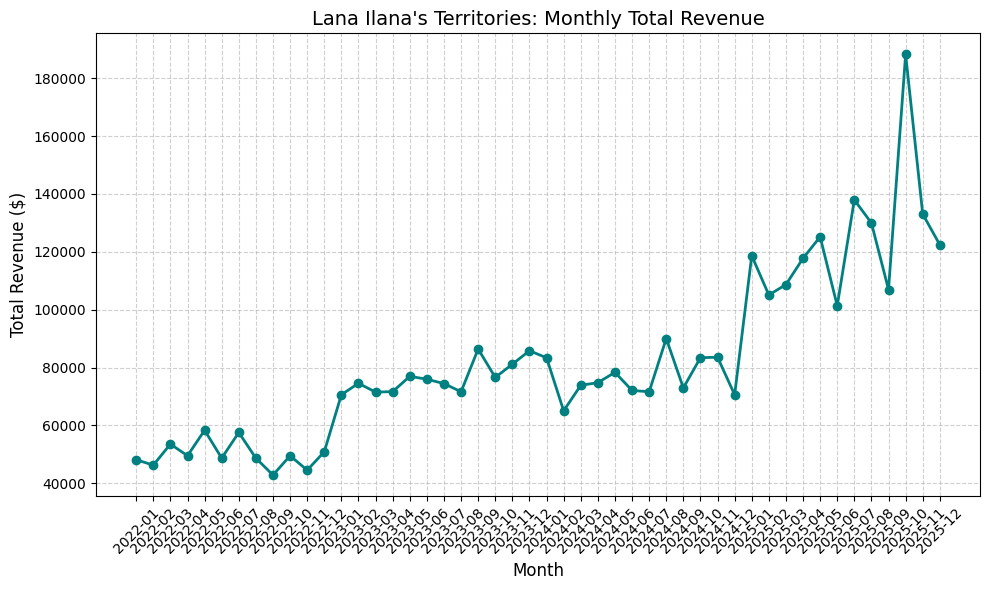

In [26]:
# Visualization 1: Monthly Total Revenue Trend
monthly_revenue['Month_Str'] = monthly_revenue['Month'].astype(str)
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue['Month_Str'], monthly_revenue['Revenue'], marker='o', color='teal', linestyle='-', linewidth=2)

# Add titles and labels
plt.title("Lana Ilana's Territories: Monthly Total Revenue", fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

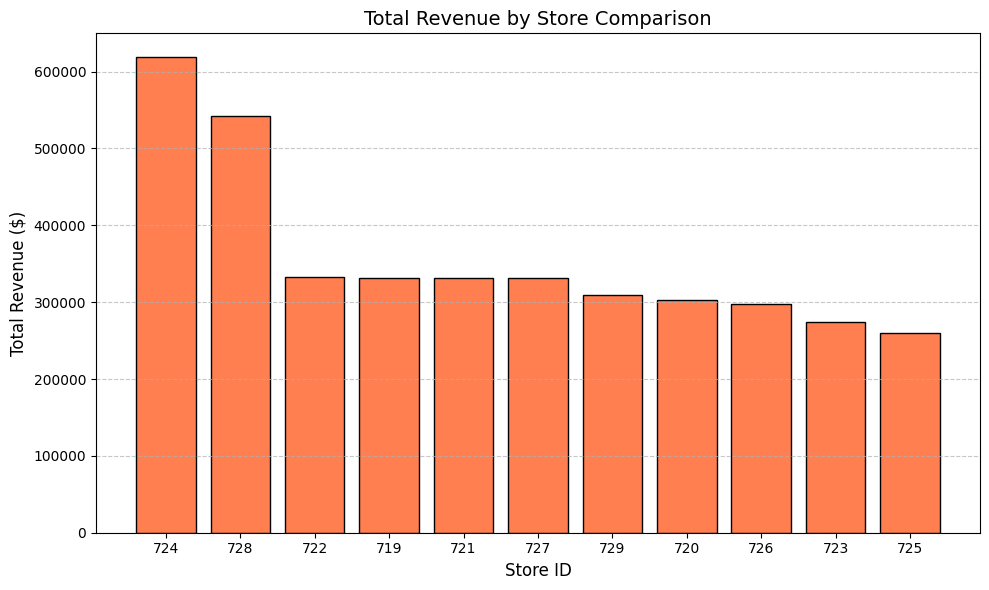

In [27]:
# Visualization 2: Store Sales Performance Comparison

stores = top_stores['Store ID'].astype(int).astype(str)
revenues = top_stores['Revenue']

plt.figure(figsize=(10, 6))
plt.bar(stores, revenues, color='coral', edgecolor='black')

# Add titles and labels
plt.title('Total Revenue by Store Comparison', fontsize=14)
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Add a horizontal grid to easily compare heights
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

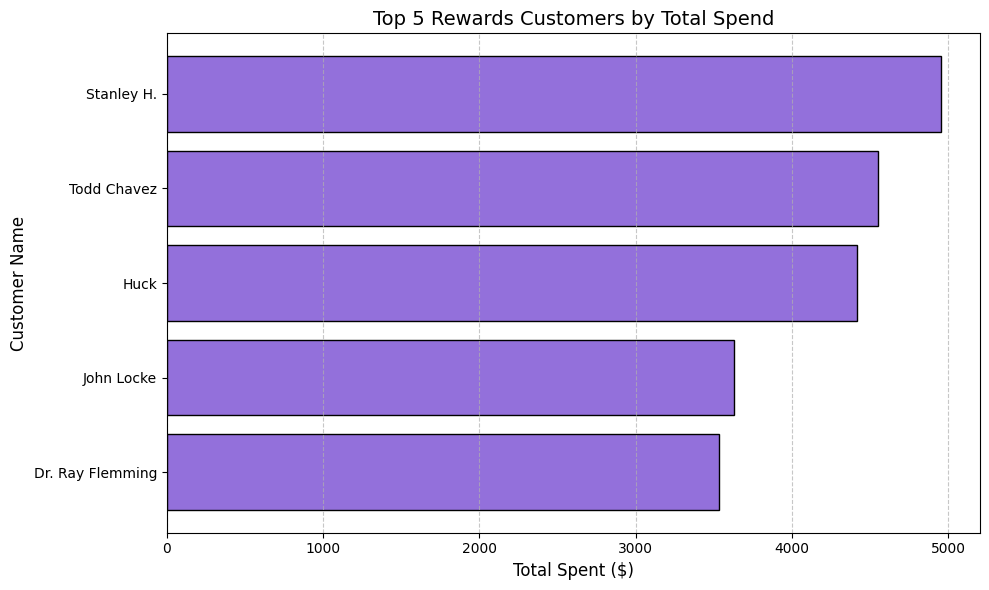

In [28]:
# Visualization 3: Top 5 Customers by Revenue
plt.figure(figsize=(10, 6))
plt.barh(top_customers['name'], top_customers['Sale Amount'], color='mediumpurple', edgecolor='black')

plt.title('Top 5 Rewards Customers by Total Spend', fontsize=14)
plt.xlabel('Total Spent ($)', fontsize=12)
plt.ylabel('Customer Name', fontsize=12)
plt.gca().invert_yaxis() # Puts the highest spender at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


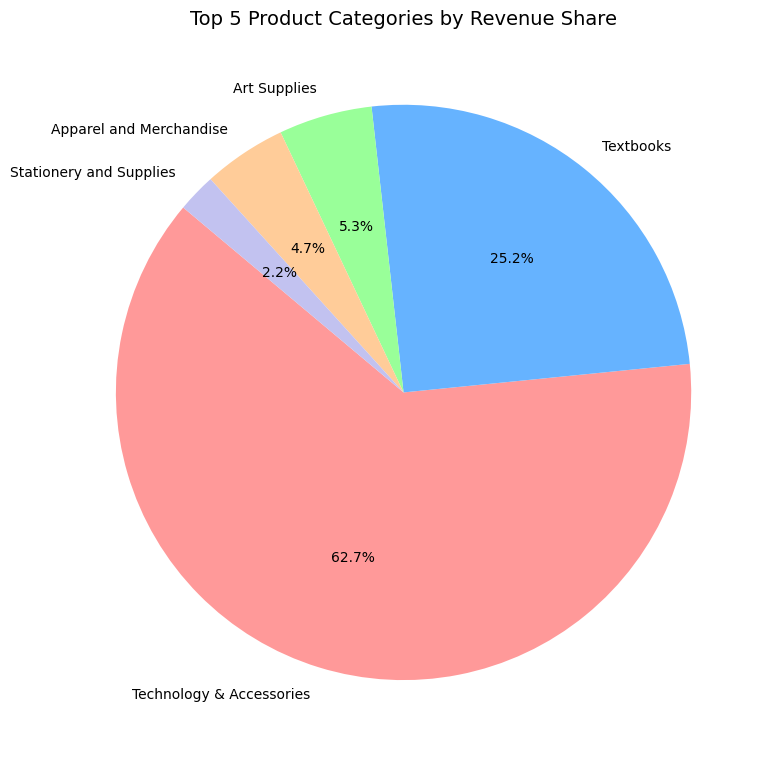

In [29]:
# Visualization 4: Revenue Distribution by Category (Top 5)
# Aggregate total revenue by category across all months
total_category_revenue = sales_full.groupby('Category')['Sale Amount'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 8))
plt.pie(total_category_revenue, labels=total_category_revenue.index, autopct='%1.1f%%', 
        startangle=140, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])

plt.title('Top 5 Product Categories by Revenue Share', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
target_stores = [724, 728, '724', '728', 724.0, 728.0] 
compare_stores = sales_full[sales_full['Store ID'].isin(target_stores)]

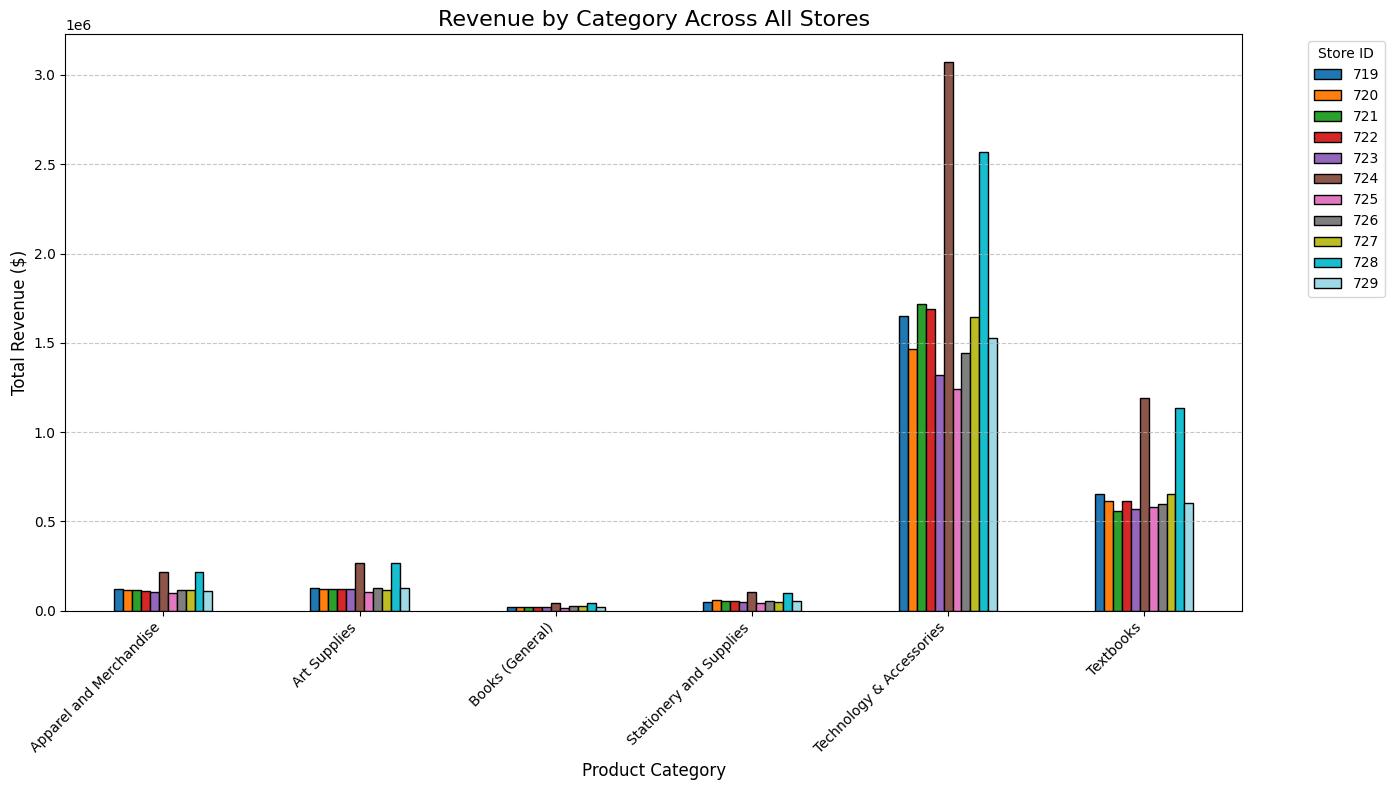

In [31]:
# Group and sum the sales by Store ID and Category for ALL stores in the territory
store_category_sales_all = sales_full.groupby(['Store ID', 'Category'])['Sale Amount'].sum().reset_index()

# Pivot the table to plot the bars side-by-side for every store
pivot_sales_all = store_category_sales_all.pivot(index='Category', columns='Store ID', values='Sale Amount').fillna(0)

# Visualization (Grouped Bar Chart)
# We use a larger figsize (14, 8) and a colormap with more colors ('tab20') because there are many stores
pivot_sales_all.plot(kind='bar', figsize=(14, 8), colormap='tab20', edgecolor='black')

# Titles and Labels
plt.title('Revenue by Category Across All Stores', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Make X-axis labels readable and add a horizontal grid
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Move the legend outside the plot area so it doesn't cover the bars
plt.legend(title='Store ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

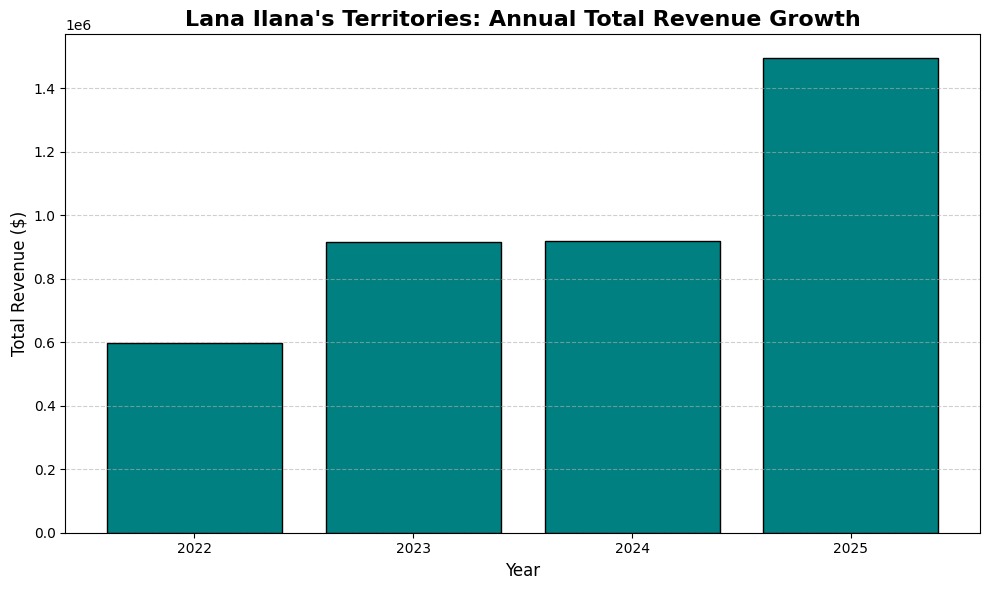

In [32]:

# 1. Extract the 'Year' from the 'Month' string (e.g., '2022-01' becomes '2022')
monthly_revenue['Year'] = monthly_revenue['Month'].astype(str).str[:4]

# 2. Group by Year to calculate annual total revenue
yearly_revenue = monthly_revenue.groupby('Year')['Revenue'].sum().reset_index()

# 3. Plot the Annual Revenue Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(yearly_revenue['Year'], yearly_revenue['Revenue'], color='teal', edgecolor='black')

# Add titles and labels
plt.title("Lana Ilana's Territories: Annual Total Revenue Growth", fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Add the specific dollar amounts (K and M format) on top of each bar
# Add horizontal grid lines for easy reading
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()

In [33]:
df_sales['Store ID'] = pd.to_numeric(df_sales['Store ID'], errors='coerce')
df_store['Store ID'] = pd.to_numeric(df_store['Store ID'], errors='coerce')

df = df_sales.merge(df_store, on='Store ID')

lana = df[df['Territory Manager'] == 'Lana Ilana']

rewards_by_store = lana.groupby('Store ID').agg(
    total_transactions=('Sale Amount', 'count'),
    rewards_transactions=('RewardsID', 'count'),
    city=('Store Location', 'first'),
    state=('State', 'first')
).reset_index()

rewards_by_store['rewards_rate_%'] = (
    rewards_by_store['rewards_transactions'] / rewards_by_store['total_transactions'] * 100
).round(1)

rewards_by_store = rewards_by_store.sort_values('rewards_rate_%', ascending=False)

print(rewards_by_store)

    Store ID  total_transactions  rewards_transactions             city  \
9        728                4320                   499      Tallahassee   
2        721                2280                   261     Jacksonville   
6        725                1937                   215           Naples   
10       729                2226                   242            Tampa   
7        726                2271                   241          Orlando   
5        724                4457                   470            Miami   
1        720                2277                   237  Fort Lauderdale   
3        722                2228                   231         Key West   
4        723                2144                   220         Lakeland   
8        727                2235                   218          Sebring   
0        719                2241                   198   Cape Canaveral   

      state  rewards_rate_%  
9   Florida            11.6  
2   Florida            11.4  
6   Flori

In [34]:
# Average spend per rewards customer (sum first, then mean across customers)
spend_per_customer = rewards_sales.groupby('RewardsID')['Sale Amount'].sum()
avg_rewards_customer = spend_per_customer.mean()

# Top 5 average
top5_avg = top_spenders['Sale Amount'].mean()

# Ratio
ratio = top5_avg / avg_rewards_customer

# Rewards program penetration
rewards_pct = rewards_sales.shape[0] / lana_sales.shape[0] * 100

print(f"Average rewards customer spend: ${avg_rewards_customer:,.2f}")
print(f"Top 5 average spend:            ${top5_avg:,.2f}")
print(f"Top 5 vs average ratio:         {ratio:.1f}x")
print(f"Rewards program penetration:    {rewards_pct:.1f}%")
print(f"Total transactions:             {lana_sales.shape[0]:,}")
print(f"Rewards transactions:           {rewards_sales.shape[0]:,}")

Average rewards customer spend: $843.71
Top 5 average spend:            $4,217.55
Top 5 vs average ratio:         5.0x
Rewards program penetration:    10.6%
Total transactions:             28,616
Rewards transactions:           3,032
